# Classification Problem — Trial Models & Findings
### Adapted from Javier's `phase2/model_dev.ipynb` · 21 September 2026

**Status: exploratory development validation — not an independent final test.**

This companion follows Javier's flow: load data → order-level features → model training → evaluation → stakeholder coverage. His notebook is unchanged. This version adds chronological moving-window validation, label-maturity checks, logistic/CatBoost baselines, feature ablations, fixed ensembles, paired uncertainty and publication-style figures.

**How to use:** the executed outputs can be viewed immediately after upload. Run all cells to regenerate the tables/charts from the embedded result snapshot; the default mode requires a Python notebook kernel with NumPy, pandas, Matplotlib and Jinja2 (formatted tables). No raw orders or local prediction CSVs are required. Full training reproduction is an explicit opt-in near the end and requires the repository, bundled data and dependencies. Outputs are exported to `andrew_findings_figures/` beside the current working directory.

**Attribution/change log:** Javier established the source notebook and operational daily-scoring/coverage framing. This companion uses the separate corrected Python implementation and its saved results, rather than rerunning Javier's original random split. Fitting is monthly, scoring and capacity selection are daily. The target is defined at approval; this is not daily model retraining or a daily count forecast.

## 1. Environment and portable result snapshot

The compressed cell below contains aggregate results, exact April PR-curve coordinates and binned calibration summaries, plus source hashes. It contains no order/customer/seller identifiers. It is a fixed snapshot, not a live reload of possibly changed files. Rebuild this notebook after new experiments.

In [1]:
from pathlib import Path
import base64, json, zlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['STIXGeneral', 'DejaVu Serif'],
    'mathtext.fontset': 'stix', 'text.usetex': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 9, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .18, 'grid.linewidth': .6,
    'figure.dpi': 120, 'savefig.dpi': 300, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'svg.fonttype': 'none',
})
FIG_DIR = Path.cwd() / 'andrew_findings_figures'
FIG_DIR.mkdir(exist_ok=True)
def export(fig, name):
    for suffix in ['pdf', 'svg', 'png']:
        fig.savefig(FIG_DIR / f'{name}.{suffix}', bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)

LABELS = {
 'base_logistic_regression': 'Original logistic',
 'purchase_distance_logistic_regression': 'Timing + distance logistic',
 'purchase_distance_random_forest': 'Timing + distance RF',
 'purchase_distance_xgboost': 'Timing + distance XGBoost',
 'purchase_distance_catboost': 'Timing + distance CatBoost',
 'ensemble_logistic_catboost': 'Logistic + CatBoost',
 'ensemble_all_four': 'Four-model blend', 'dummy_prior': 'Prior baseline',
}
SELECTED = ['base_logistic_regression', 'purchase_distance_catboost', 'ensemble_logistic_catboost']
COLORS = dict(zip(SELECTED, ['#0072B2', '#D55E00', '#009E73']))

In [2]:
SNAPSHOT = json.loads(zlib.decompress(base64.b64decode('...')))
print('Loaded embedded development snapshot; no training or threshold selection performed.')

Loaded embedded development snapshot; no training or threshold selection performed.


## 2. Data, target and leakage boundaries

One row per order, from Olist orders/customers/items/products/sellers/payments. One-to-many tables are aggregated before joining. The retrospective population is eventual delivered orders with valid dates; impossible negative delivery durations are excluded.

An order is late if its actual delivery calendar date is after its promised calendar date. Actual outcomes, carrier handoff, status and reviews are not predictor inputs. The promise-end maturity gate applies to both classes; overdue pending deliveries are retained in training as late rather than selected out by completion speed.

**Limits that tests cannot remove:** final payment/product/promise values and the static geographic reference are not historically versioned. Their availability at approval is assumed. Eventual-delivery membership is retrospective and excludes cancellations/unresolved orders. These results do not establish performance on all live approvals. “Leakage-guarded under explicit assumptions” is accurate; “proven leakage-free” is not.

In [3]:
backtest = SNAPSHOT['classification_backtest_results']
folds = pd.DataFrame(backtest['folds'])
display(folds[['fold', 'train_rows', 'train_approval_start', 'train_approval_end',
               'validation_start', 'validation_end', 'validation_rows', 'validation_late_rate']]
        .style.format({'validation_late_rate': '{:.2%}'}))
assert folds.validation_rows.sum() == 40056
print('40,056 development orders per model; no final holdout evaluated.')

,fold,train_rows,train_approval_start,train_approval_end,validation_start,validation_end,validation_rows,validation_late_rate
0,1,20878,2017-04-05,2017-10-01,2017-11-01,2017-11-30,7149,12.23%
1,2,22835,2017-05-05,2017-10-31,2017-12-01,2017-12-31,5675,7.86%
2,3,26595,2017-06-05,2017-12-01,2018-01-01,2018-01-31,6991,5.68%
3,4,28783,2017-07-06,2018-01-01,2018-02-01,2018-02-28,6534,13.62%
4,5,31405,2017-08-03,2018-01-29,2018-03-01,2018-03-31,7083,19.20%
5,6,34842,2017-09-03,2018-03-01,2018-04-01,2018-04-30,6624,4.62%


40,056 development orders per model; no final holdout evaluated.


## 3. Feature engineering and model training

**Original features:** approval timing, promised lead time, order composition, freight, product weight/volume, geography and payment summaries.

**Enriched bundle (+19):** parcel ratios, product/payment categories, state route, purchase-to-approval delay, promise weekday and cyclic timing. **Purchase bundle (+10):** order-placement weekday/hour/month, weekend and sine/cosine encodings. **Distance bundle (+5):** mean/max unique-seller distance, missing fraction, log mean distance and distance per positive promised day.

Distances are Haversine straight-line postcode-location proxies, not actual carrier routes. Median coordinates per postcode follow a broad Brazil plausibility filter; missing coordinates remain missing. The fixed, full-archive lookup is outcome-free but historically unversioned.

All models use the same moving 180-day approval window ending 30 days before each monthly origin, and only labels mature by that origin. Imputation/scaling/encoding fit within training folds. Logistic regression, Random Forest and XGBoost retain the fixed pilot settings; CatBoost uses 300 iterations, depth 6, learning rate 0.05 and balanced weights. No outer-fold early stopping, tuning or learned ensemble weights.

This companion evaluates fixed configurations. It does **not** yet provide nested tuning, SHAP analysis, calibration fitting or independent final evaluation.

## 4. Evaluation protocol: more than precision

Primary ranking: equal-month mean **average precision (AP)**. AP weights precision by recall increments and differs from trapezoidal PR-AUC. Supplementary: ROC-AUC and explicitly labelled trapezoidal PR-AUC. Threshold decisions: precision, recall, F1, balanced accuracy, MCC and confusion counts. Probability quality: Brier/MSE and log loss; reliability diagrams below. Operational evaluation: precision, coverage/recall and lift at matched daily capacity.

For binary probabilities, $\mathrm{Brier}=n^{-1}\sum_i(p_i-y_i)^2$, so probability MSE is already reported; RMSE is its square root. Regression MAE/RMSE in days or counts belong to a separately agreed regression/forecasting problem.

Thresholds use **earlier** out-of-fold predictions whose labels have matured by the current origin; first-fold fallback is 0.5. Daily capacity uses ceiling-rounded review counts and expected capture under random tie-breaking. Nominal 10% is provisional, not a stakeholder-confirmed budget. AP significance tests do not establish significance for secondary metrics.

In [4]:
metrics = SNAPSHOT['classification_metric_summary']['models']
ranking = pd.DataFrame({LABELS[n]: {k: r[k] for k in
    ['mean_fold_ap', 'mean_fold_roc_auc', 'brier_score', 'log_loss']} for n, r in metrics.items()}).T
ranking.columns = ['Mean monthly AP ↑', 'Mean monthly ROC-AUC ↑', 'Pooled Brier ↓', 'Pooled log loss ↓']
display(ranking.style.format('{:.4f}'))
decisions = pd.DataFrame({LABELS[n]: {k: r[k] for k in
    ['forward_precision', 'forward_recall', 'forward_f1', 'forward_balanced_accuracy', 'forward_mcc', 'forward_alert_fraction']}
    for n, r in metrics.items()}).T
display(decisions.style.format('{:.4f}'))
print('Threshold metrics are pooled prospective decisions, not matched review budgets.')

,Mean monthly AP ↑,Mean monthly ROC-AUC ↑,Pooled Brier ↓,Pooled log loss ↓
Original logistic,0.1981,0.6798,0.1554,0.4856
Prior baseline,0.1053,0.5000,0.0981,0.3629
Four-model blend,0.1961,0.6803,0.1416,0.4514
Logistic + CatBoost,0.2012,0.6788,0.1730,0.5223
Timing + distance CatBoost,0.1912,0.6624,0.1579,0.4878
Timing + distance logistic,0.1978,0.6732,0.2261,0.6610
Timing + distance RF,0.1816,0.6640,0.1122,0.3822
Timing + distance XGBoost,0.1801,0.6564,0.1466,0.4577


,forward_precision,forward_recall,forward_f1,forward_balanced_accuracy,forward_mcc,forward_alert_fraction
Original logistic,0.1266,0.4133,0.1938,0.5364,0.0471,0.3483
Prior baseline,0.1033,0.7955,0.1828,0.4854,-0.0235,0.8215
Four-model blend,0.1655,0.4915,0.2476,0.5978,0.1298,0.3168
Logistic + CatBoost,0.1542,0.5788,0.2435,0.5998,0.1257,0.4005
Timing + distance CatBoost,0.1426,0.4196,0.2128,0.5591,0.0786,0.3140
Timing + distance logistic,0.1505,0.5869,0.2396,0.5957,0.1199,0.4159
Timing + distance RF,0.1234,0.5106,0.1987,0.5386,0.0480,0.4416
Timing + distance XGBoost,0.1461,0.3840,0.2117,0.5580,0.0797,0.2804


Threshold metrics are pooled prospective decisions, not matched review budgets.


### Figure 1. Performance changes across months

The six monthly scores are actual fold observations, not confidence intervals. The prior-baseline AP equals each month's late prevalence. This plot explains why a single mean does not characterise future-month uncertainty.

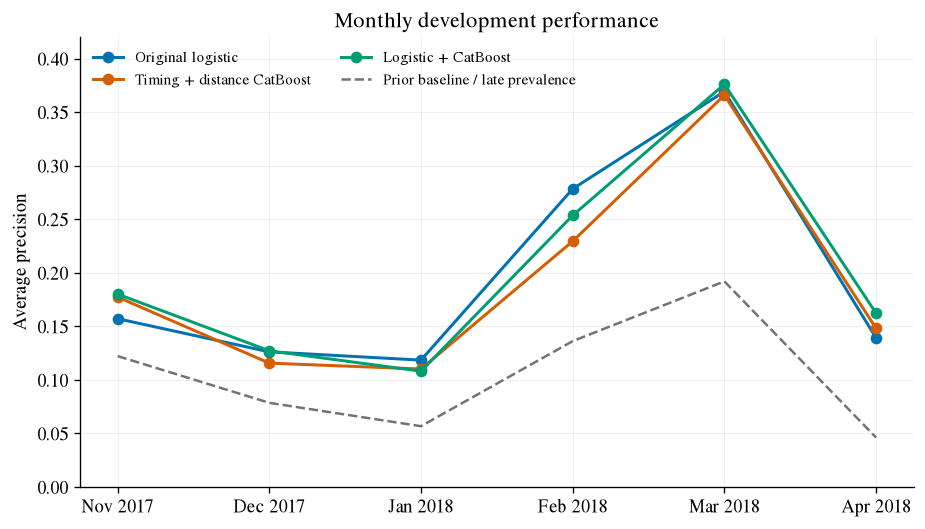

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.3), layout='constrained')
months = pd.to_datetime(folds.validation_start).dt.strftime('%b %Y')
for name in SELECTED:
    values = [r['average_precision'] for r in metrics[name]['fold_ranking']]
    ax.plot(months, values, marker='o', linewidth=1.8, color=COLORS[name], label=LABELS[name])
ax.plot(months, folds.validation_late_rate, '--', color='.45', label='Prior baseline / late prevalence')
ax.set(ylabel='Average precision', title='Monthly development performance', ylim=(0, .42))
ax.legend(frameon=False, ncol=2, loc='upper left')
export(fig, '01_monthly_average_precision')

### Figure 2. Feature-bundle ablation

These are sequential additions, not a full factorial experiment. In particular, distance without purchase timing was not tested. Lines connect observed equal-month means; they are not uncertainty bands.

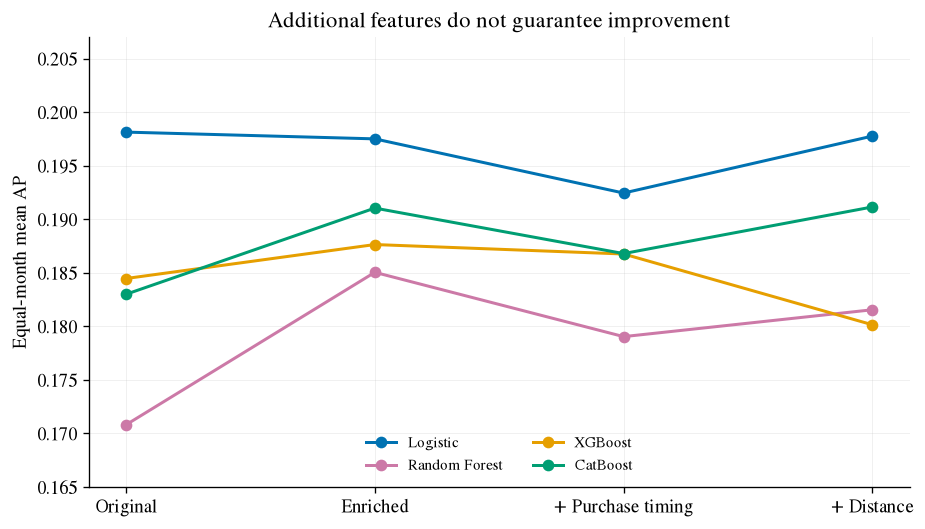

In [6]:
first = SNAPSHOT['classification_experiment_results']['models']
later = SNAPSHOT['classification_time_distance_results']['models']
fig, ax = plt.subplots(figsize=(7.6, 4.3), layout='constrained')
for name, label, color in [('logistic_regression', 'Logistic', '#0072B2'),
    ('random_forest', 'Random Forest', '#CC79A7'), ('xgboost', 'XGBoost', '#E69F00'),
    ('catboost', 'CatBoost', '#009E73')]:
    entries = [first['base_' + name], first['enriched_' + name], later['purchase_' + name], later['purchase_distance_' + name]]
    values = [r['fold_summary']['average_precision']['mean'] for r in entries]
    ax.plot(['Original', 'Enriched', '+ Purchase timing', '+ Distance'], values,
            marker='o', linewidth=1.8, label=label, color=color)
ax.set(ylabel='Equal-month mean AP', title='Additional features do not guarantee improvement', ylim=(.165, .207))
ax.legend(frameon=False, ncol=2, loc='lower center')
export(fig, '02_feature_ablation')

### Figure 3. Precision–recall and operational capacity

Left: exact PR curves for **April 2018 only**, the final development fold, so the curves do not conflate score scales across refits. AP in the legend is April AP, not the six-fold mean. April was already used for development, not a final test. Right: pooled captured late orders under within-day capacity selection across all six months. These answer different questions; no uncertainty bands are claimed.

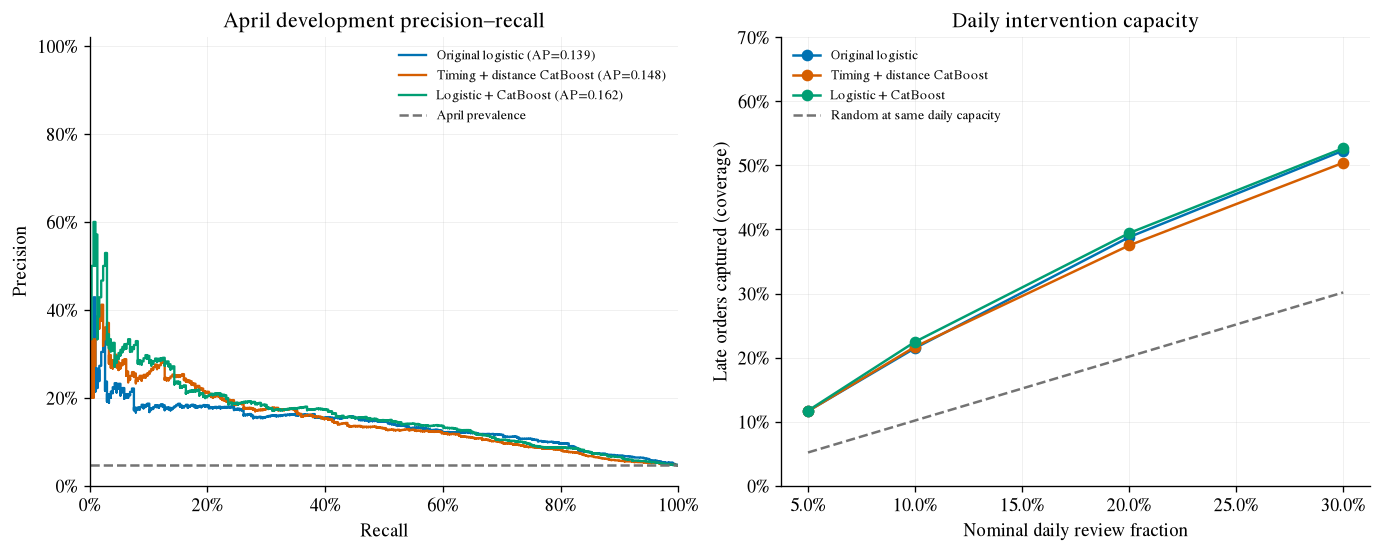

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5), layout='constrained')
for name in SELECTED:
    d = SNAPSHOT['diagnostics'][name]
    axes[0].step(d['recall'], d['precision'], where='post', color=COLORS[name], linewidth=1.4,
                 label=f"{LABELS[name]} (AP={d['april_ap']:.3f})")
    x = np.array([5, 10, 20, 30]) / 100
    y = [metrics[name]['capacity'][f'coverage_at_{k}pct'] for k in [5, 10, 20, 30]]
    axes[1].plot(x, y, marker='o', color=COLORS[name], label=LABELS[name])
axes[0].axhline(d['april_prevalence'], color='.45', linestyle='--', label='April prevalence')
axes[0].set(xlabel='Recall', ylabel='Precision', title='April development precision–recall', xlim=(0, 1), ylim=(0, 1.02))
random_y = [metrics['dummy_prior']['capacity'][f'coverage_at_{k}pct'] for k in [5, 10, 20, 30]]
axes[1].plot(x, random_y, '--', color='.45', label='Random at same daily capacity')
axes[1].set(xlabel='Nominal daily review fraction', ylabel='Late orders captured (coverage)', title='Daily intervention capacity', ylim=(0, .7))
for ax in axes:
    ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(frameon=False, fontsize=8, loc='upper right' if ax is axes[0] else 'upper left')
export(fig, '03_precision_recall_and_capacity')

### Figure 4. Probability quality, not just ranking

Reliability uses ten fixed equal-width probability bins; only occupied bins are shown. The companion panel shows bin counts because sparse bins are uncertain. These descriptive plots have no calibration confidence intervals, pool changing months and do not fit a calibrator. Class weighting can shift probability levels. Brier and log loss assess more than calibration alone.

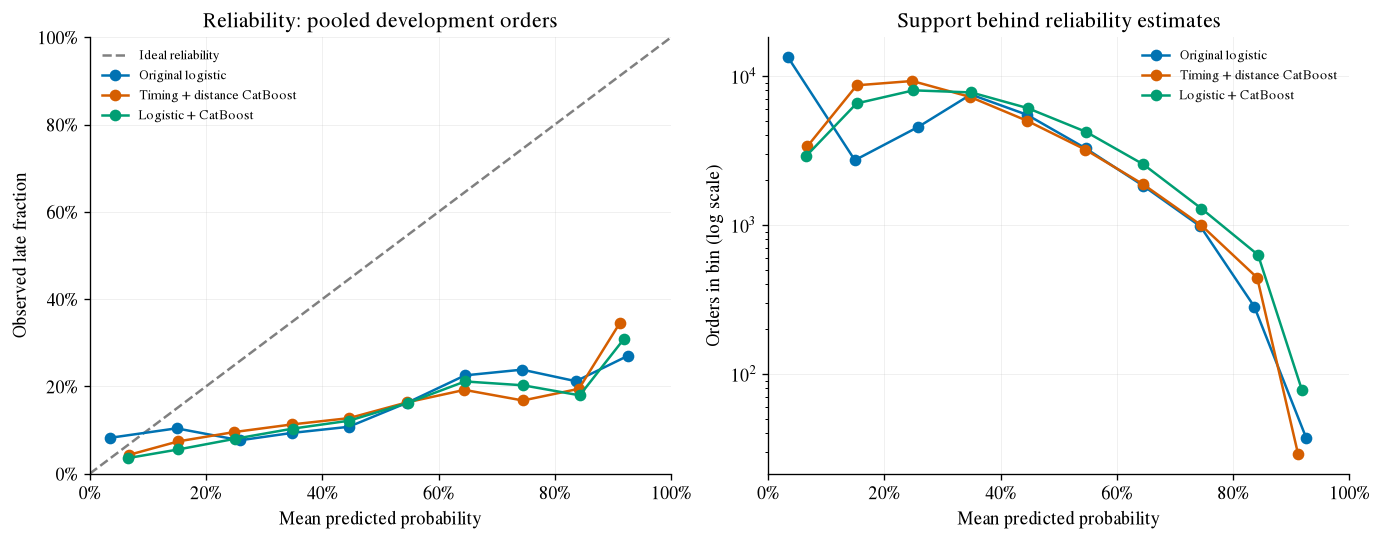

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.4), layout='constrained')
axes[0].plot([0, 1], [0, 1], '--', color='.5', label='Ideal reliability')
for name in SELECTED:
    bins = pd.DataFrame(SNAPSHOT['diagnostics'][name]['reliability'])
    axes[0].plot(bins.mean_probability, bins.observed_late_rate, marker='o', color=COLORS[name], label=LABELS[name])
    axes[1].plot(bins.mean_probability, bins['count'], marker='o', color=COLORS[name], label=LABELS[name])
axes[0].set(xlabel='Mean predicted probability', ylabel='Observed late fraction', title='Reliability: pooled development orders', xlim=(0, 1), ylim=(0, 1))
axes[1].set(xlabel='Mean predicted probability', ylabel='Orders in bin (log scale)', title='Support behind reliability estimates', yscale='log', xlim=(0, 1))
for ax in axes:
    ax.legend(frameon=False, fontsize=8); ax.xaxis.set_major_formatter(PercentFormatter(1))
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
export(fig, '04_probability_reliability')

## 5. Ensembles and paired statistical comparison

Random Forest and boosting are already ensembles. We additionally tested equal-probability voting across logistic/CatBoost and all four models. Component configurations are the timing-plus-distance versions. No blend weights are fit to validation outcomes; each blend receives its own forward threshold.

The two-model blend has mean AP **0.20124**, versus **0.19814** for original logistic, but its gain is not established statistically: difference **+0.00310**, marginal seven-day 95% interval **[−0.00188, 0.00844]**, Holm-adjusted approximate **p=0.792**. The blend's Brier score is worse (0.1730 versus 0.1554). No final winner is declared.

Paired circular date-block bootstrap resamples within each fixed validation month, with 1,999 replicates, primary 7-day blocks and 3/14-day sensitivity checks. The metric is equal-month mean AP. Approximate two-sided p-values use null-centered bootstrap differences; Holm covers six comparisons against original logistic **in this batch**, not all adaptive project experiments. Intervals are marginal, not simultaneous. Fixed predictions/months omit training variability, new-month uncertainty and adaptive-search bias.

,candidate,delta_macro_ap,ci95_percentile,p_holm
0,ensemble_all_four,-0.002016,"[-0.00704922585256131, 0.002850970351043072]",0.8310
1,ensemble_logistic_catboost,0.003101,"[-0.0018847387859932327, 0.008439401581127477]",0.7920
2,purchase_distance_catboost,-0.006987,"[-0.01222797247293093, -0.001052529655254582]",0.0560
3,purchase_distance_logistic_regression,-0.000369,"[-0.006151542629142942, 0.007749501025545846]",0.9195
4,purchase_distance_random_forest,-0.016590,"[-0.023265249907216595, -0.00927135904218773]",0.0030
5,purchase_distance_xgboost,-0.017994,"[-0.02393640381462989, -0.011741197015794774]",0.0030


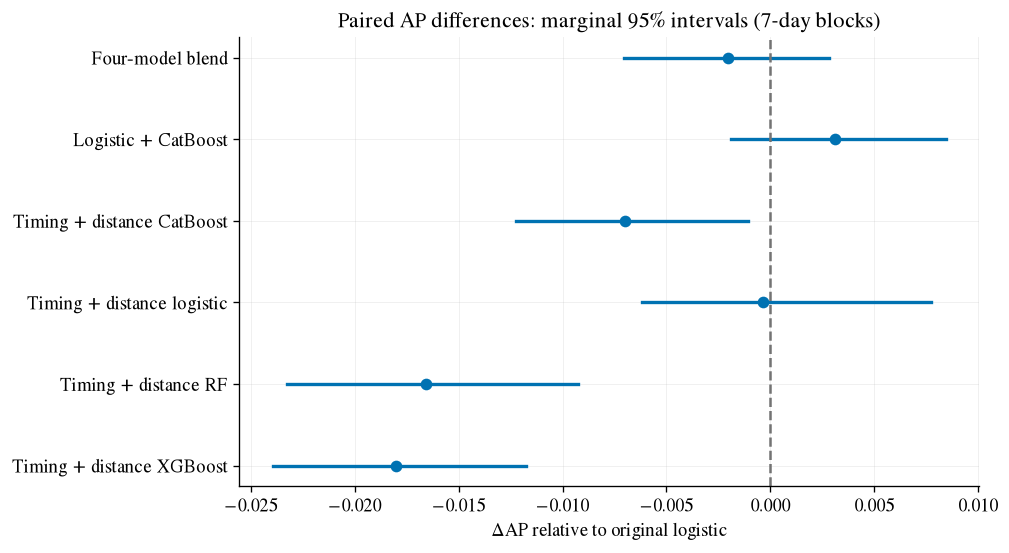

,7-day adjusted p,3-day adjusted p,14-day adjusted p
ensemble_all_four,0.8310,0.9945,0.7080
ensemble_logistic_catboost,0.7920,0.9945,0.6420
purchase_distance_catboost,0.0560,0.1280,0.0480
purchase_distance_logistic_regression,0.9195,0.9945,0.8840
purchase_distance_random_forest,0.0030,0.0030,0.0030
purchase_distance_xgboost,0.0030,0.0030,0.0030


In [9]:
analyses = SNAPSHOT['classification_ensemble_significance']['analyses']
comparison = pd.DataFrame(analyses[0]['comparisons'])
display(comparison[['candidate', 'delta_macro_ap', 'ci95_percentile', 'p_holm']])
fig, ax = plt.subplots(figsize=(8.3, 4.5), layout='constrained')
for i, row in comparison.iterrows():
    lo, hi = row.ci95_percentile
    ax.plot([lo, hi], [i, i], color='#0072B2', linewidth=2)
    ax.plot(row.delta_macro_ap, i, 'o', color='#0072B2')
ax.axvline(0, linestyle='--', color='.45')
ax.set_yticks(range(len(comparison)), [LABELS[n] for n in comparison.candidate])
ax.invert_yaxis()
ax.set(xlabel=r'$\Delta\mathrm{AP}$ relative to original logistic',
       title='Paired AP differences: marginal 95% intervals (7-day blocks)')
export(fig, '05_paired_ap_differences')
sensitivity = pd.DataFrame({a['block_days']: {r['candidate']: r['p_holm'] for r in a['comparisons']} for a in analyses})
sensitivity.columns = [f'{d}-day adjusted p' for d in sensitivity.columns]
display(sensitivity.style.format('{:.4f}'))

## 6. Findings and report-ready discussion

1. Original logistic remains a strong benchmark. Additional model complexity alone does not establish a gain.
2. The initial enrichment improved RF and CatBoost versus their original versions in the earlier exploratory paired analysis. Purchase-time/distance additions did not provide a clear further AP improvement.
3. The fixed logistic/CatBoost blend has the highest observed mean AP in the latest batch, but the improvement is small and statistically inconclusive. Daily top-10% coverage is 22.47% versus 21.48% for original logistic; this coverage difference has not been significance-tested.
4. Ranking and probability quality differ. Calibration assessment and unweighted alternatives remain necessary before interpreting risk scores as absolute probabilities or summing them into expected counts.
5. Nine leakage/ensemble tests plus the metric-report test pass (ten total). These verify implementation behaviours, not historical data availability or population validity.

**Suggested report paragraph:** We evaluated late-delivery classifiers using six chronological moving-window folds, with training-label maturity gates and fold-fitted preprocessing. Average precision was the primary ranking measure, supplemented by prospective decision metrics, probability losses and daily capacity-based coverage. Feature and voting experiments produced modest gains in some development metrics, but the logistic/CatBoost blend did not establish a statistically significant AP advantage over the original logistic benchmark. Results remain conditional on a retrospective delivered-order population and unverified historical feature snapshots; independent final evaluation is pending.

**Next:** agree cancellation/unresolved-order treatment and the scoring-time feature contract; use inner chronological tuning/calibration; freeze the pipeline and capacity policy; evaluate a genuinely uninspected mature cohort if available. May–June was already inspected and must not be relabelled untouched. Learned stacking, if attempted, needs inner chronological OOF predictions and mature meta-model labels.

## 7. Optional full reproduction (off by default)

This section deliberately does nothing unless `RUN_FULL_PIPELINE=True`. It requires the repository and data, not merely this portable notebook. Install `phase2/requirements.txt` in the active environment first. On macOS, XGBoost may additionally require OpenMP. Commands use the current kernel's Python. Reproduction rewrites generated result files but does not alter Javier's notebook. Rebuild this companion afterwards to refresh its embedded snapshot and figures.

The source notebook's flow is retained conceptually; reusable feature/training code is in the companion `.py` files to avoid divergent notebook-only implementations.

In [10]:
RUN_FULL_PIPELINE = False
if RUN_FULL_PIPELINE:
    import subprocess, sys
    candidates = [Path.cwd(), *Path.cwd().parents]
    repo = next((p for p in candidates if (p / 'phase2/model_workbench.py').exists()), None)
    if repo is None:
        raise FileNotFoundError('Open this notebook inside the full project repository.')
    commands = [
        [sys.executable, '-m', 'unittest', 'discover', '-s', 'phase2', '-p', 'test_*.py'],
        *[[sys.executable, 'phase2/' + script] for script in [
            'classification_backtest.py', 'classification_experiments.py',
            'classification_significance.py', 'classification_time_distance.py',
            'classification_ensembles.py', 'classification_metric_report.py']],
    ]
    for command in commands:
        subprocess.run(command, cwd=repo, check=True)
    print('Reproduction complete. Rebuild this notebook to refresh its snapshot; do not mistake old embedded outputs for this new run.')
else:
    print('Full retraining skipped. All displayed findings come from the embedded verified snapshot.')

Full retraining skipped. All displayed findings come from the embedded verified snapshot.


## 8. Exports, provenance and references

Five figures are exported as vector PDF/SVG plus 300-dpi PNG. Serif/STIX mathematical typography is LaTeX-like but requires no TeX installation. In a LaTeX report, use the PDF with `\includegraphics[width=\linewidth]{01_monthly_average_precision.pdf}`. Uploaded notebook outputs embed the charts, so viewers do not need the export folder.

Method references: [AP versus trapezoidal PR-AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html), [probability calibration and proper scores](https://scikit-learn.org/stable/modules/calibration.html), [CatBoost categorical processing](https://catboost.ai/docs/en/features/categorical-features), [CatBoost paper](https://papers.neurips.cc/paper_files/paper/2018/file/14491b756b3a51daac41c24863285549-Paper.pdf). Additional interpretation is in the repository's evaluation guide and experiment findings.

Hashes below identify the files used when assembling the snapshot. They provide lineage, not proof that historical source values were available at prediction time.

In [11]:
display(pd.DataFrame(SNAPSHOT['provenance'].items(), columns=['Source file', 'SHA-256']))
print('Export directory:', FIG_DIR)
print('Figures:', ', '.join(p.name for p in sorted(FIG_DIR.glob('*.pdf'))))
print('Model-fit versions:', SNAPSHOT['classification_experiment_results']['versions'])

,Source file,SHA-256
0,classification_backtest_results.json,bd75da8f111ec0c364b1ad80d5f2fc306662e90c29bdae...
1,classification_experiment_results.json,d7633c7aa6dc31d0cc835ea1b134b87f8d285758ec386a...
2,classification_time_distance_results.json,35c5d43393eb04375d088f1c3a5a96fa7588d0e49d93d6...
3,classification_ensemble_results.json,63fe14ee1480318c2df1ceeab5168e42ae38b881c3dbad...
4,classification_ensemble_significance.json,fbcda57f39e05612490b621e2193050e3ba8d8bae22391...
5,classification_metric_summary.json,392041b4376a5804a37ff3664bfeb4d8b9955818fbc816...
6,model_dev.ipynb,f43a533d0fcac6bf5d53eebe87500ba30c2361317e6f39...
7,classification_ensemble_predictions.csv,cf9a5b0ba401927a096a8ccc0a7ed8c01dd89121973b7d...
8,model_workbench.py,06ed28bfc00525f1c6dce7760d18f9bcc7568bd2f9932d...
9,classification_backtest.py,6dec4b3208a2e6a41606f9e49247b86154938a70da22c2...


Export directory: /Users/andrew_tjs/github/Team8_IT5006_Ecommerce_Analytics_AY2627Sem1/phase2/andrew_findings_figures
Figures: 01_monthly_average_precision.pdf, 02_feature_ablation.pdf, 03_precision_recall_and_capacity.pdf, 04_probability_reliability.pdf, 05_paired_ap_differences.pdf
Model-fit versions: {'catboost': '1.2.10', 'scikit-learn': '1.9.1', 'xgboost': '3.4.1'}
